**Portfolio Backtester**

**Author:** Rafaela Garrovillo 

## What is this project?

This is a **portfolio backtester**. A tool that tests how an investment strategy would have performed historically. You can simply input a list of stocks, weights for each one, and a date range. The tool then calculates how the portfolio would have grown over time and compares it to just buying the S&P 500.

## Phase 1: Data Acquisition

Pulling 5 years of historical price data for a 5-stock basket spanning semiconductors, enterprise software, and aerospace:

| Ticker | Company | Sector |
|--------|---------|--------|
| NVDA | Nvidia | Semiconductors |
| INTC | Intel | Semiconductors |
| AVGO | Broadcom | Semiconductors |
| SAP  | SAP SE | Enterprise Software |
| BA   | Boeing | Aerospace & Defense |

The basket is intentionally semiconductor-heavy with one software and one industrial name — useful for analyzing sector concentration risk later in the project.

In [2]:
# importing packages
import yfinance as yf            # historical stock data
import pandas as pd              # DataFrame operations
import matplotlib.pyplot as plt  # charting

# suppressing warnings for cleaner output
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

print("Packages imported successfully.")

Packages imported successfully.


In [7]:
# pulling 5 years of historical price data for the basket
tickers = ["NVDA", "INTC", "AVGO", "SAP", "BA"]

prices = yf.download(tickers = tickers,
                     start   = "2020-01-01",
                     end     = "2025-01-01")['Close']

prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AVGO,BA,INTC,NVDA,SAP
Date,,,,,
2020-01-02,27.677490,331.348572,53.666466,5.970752,121.977531
2020-01-03,26.973522,330.791901,53.013725,5.875187,119.454346
2020-01-06,26.933167,331.766083,52.863762,5.899824,119.650497
2020-01-07,26.840448,335.285156,51.981670,5.971251,119.133377
2020-01-08,26.505630,329.410095,52.016956,5.982451,120.435097


## Data Quality Check

Validating row count, date coverage, and data integrity before any analysis.

In [8]:
# data integrity checks
print(f"Total trading days: {len(prices)}")
print(f"Date range:         {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Tickers loaded:     {list(prices.columns)}")
print(f"Missing values per ticker:")
print(prices.isnull().sum())

Total trading days: 1258
Date range:         2020-01-02 to 2024-12-31
Tickers loaded:     ['AVGO', 'BA', 'INTC', 'NVDA', 'SAP']
Missing values per ticker:
Ticker
AVGO    0
BA      0
INTC    0
NVDA    0
SAP     0
dtype: int64


In [9]:
prices.describe().round(2)

Ticker,AVGO,BA,INTC,NVDA,SAP
count,1258.00,1258.00,1258.00,1258.00,1258.00
mean,69.87,195.47,40.12,38.43,133.65
std,45.33,40.42,10.69,38.22,38.05
min,14.41,95.01,18.89,4.89,74.87
25%,41.75,168.55,30.66,13.57,109.26
50%,52.24,195.92,42.26,21.23,126.53
75%,85.70,216.72,49.19,45.61,144.24
max,246.58,345.40,62.08,148.82,248.92


## Price History

Note: NVDA and AVGO both executed 10-for-1 stock splits in mid-2024. The prices below are split-adjusted, so they reflect the historical share value on today's split-adjusted basis.

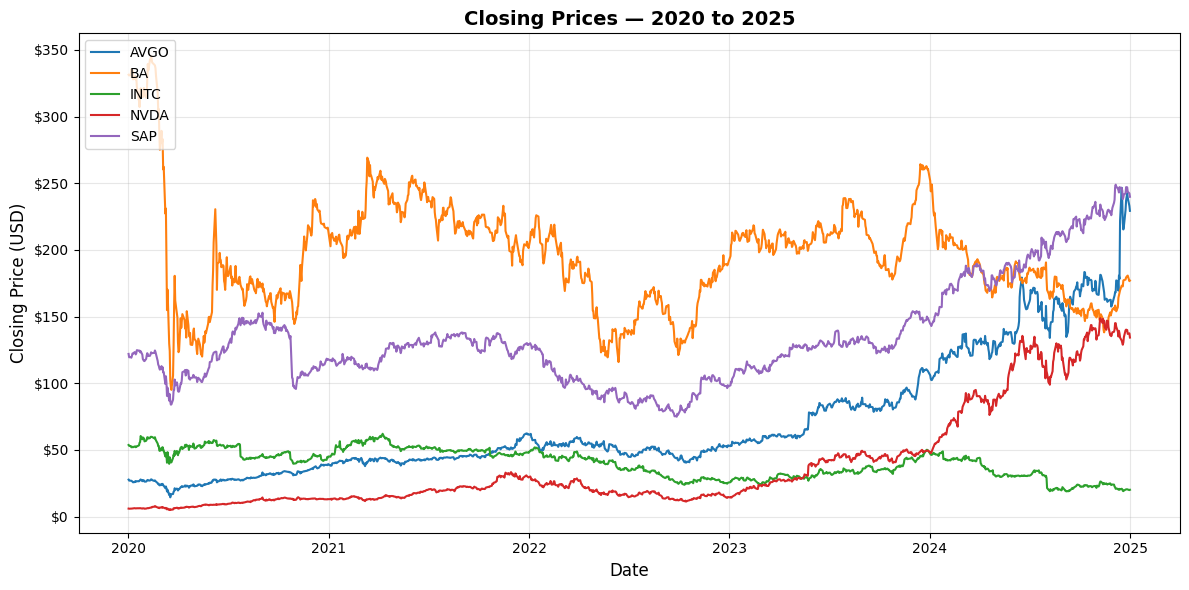

In [10]:
# plotting all five stocks on one chart
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in prices.columns:
    ax.plot(prices.index, prices[ticker], linewidth=1.5, label=ticker)

ax.set_title('Closing Prices — 2020 to 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Closing Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Normalized Performance Comparison

Raw prices make cross-stock comparison difficult because each stock trades at a different absolute level. Rebasing every stock to 100 on the start date shows percentage performance on a like-for-like basis — the standard approach for portfolio analysis.

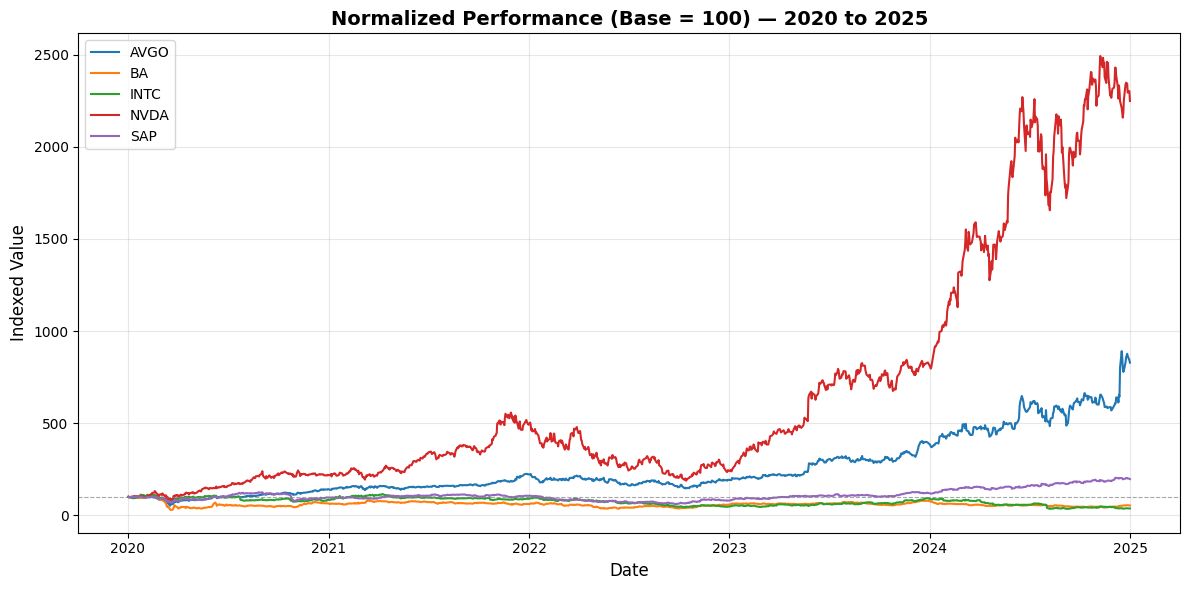

In [11]:
# rebasing all stocks to 100 on the start date
normalized = (prices / prices.iloc[0]) * 100

# plotting normalized performance
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in normalized.columns:
    ax.plot(normalized.index, normalized[ticker], linewidth=1.5, label=ticker)

ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_title('Normalized Performance (Base = 100) — 2020 to 2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Indexed Value', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Observations

- **Performance dispersion is extreme.** Over the same 5-year window, NVDA returned roughly 24x while INTC and BA finished below their starting values. Stock selection within even a small basket of large-cap names drove drastically different outcomes.

- **The AI thesis is visible in the data.** NVDA and AVGO — both semiconductor names with direct AI exposure — accelerate sharply from mid-2023 onward, while INTC (also a semi, but without comparable AI positioning) diverges in the opposite direction. Sector membership alone did not drive returns; positioning within the sector did.

- **Defensive names underperformed in absolute terms but offered stability.** SAP delivered a steady ~2x return without the volatility of the semiconductor names — a reminder that risk-adjusted returns (which I'll calculate in Phase 2) often tell a different story than total return alone.

- **Concentration risk is real.** A naive equal-weight portfolio of these five stocks would have its returns dominated by NVDA. This makes the case for studying weighting and rebalancing strategies, which the full backtester will eventually support.

## Phase 2: Returns & Performance Metrics

Prices alone don't enable comparison across stocks — a $10 move means very different things for a $50 stock versus a $500 stock. The standard fix is to convert prices into **returns**: the percentage change from one period to the next.

This phase calculates three core performance metrics for each stock in the basket:

- **Total return** — cumulative percentage gain or loss over the full period
- **Annual

In [12]:
# calculating daily returns (percentage change day-over-day)
daily_returns = prices.pct_change().dropna()

daily_returns.head()

Ticker,AVGO,BA,INTC,NVDA,SAP
Date,,,,,
2020-01-03,-0.025435,-0.001680,-0.012163,-0.016006,-0.020686
2020-01-06,-0.001496,0.002945,-0.002829,0.004193,0.001642
2020-01-07,-0.003443,0.010607,-0.016686,0.012107,-0.004322
2020-01-08,-0.012474,-0.017523,0.000679,0.001876,0.010927
2020-01-09,-0.008033,0.014998,0.005596,0.010983,0.015176


### Total Return Over the Period

Total return measures the cumulative percentage change from the first day to the last. A value of 100% means the stock doubled; -50% means it lost half its value.

In [13]:
# total return: (final price / starting price) - 1
total_return = (prices.iloc[-1] / prices.iloc[0]) - 1

# converting to percentage and sorting
total_return_pct = (total_return * 100).round(2).sort_values(ascending=False)

print("Total Return (%) — Full Period")
print("-" * 35)
print(total_return_pct)

Total Return (%) — Full Period
-----------------------------------
Ticker
NVDA    2148.39
AVGO     728.41
SAP       96.62
BA       -46.58
INTC     -62.64
dtype: float64


### Annualized Return

A 200% return over 5 years is very different from 200% in one year. Annualizing converts total return into an average yearly rate, making different time periods comparable.

The formula compounds the daily return: $(1 + \text{total return})^{(252 / n)} - 1$, where 252 is the standard trading days per year and *n* is the actual number of days in the dataset.

In [14]:
# annualized return
n_days = len(daily_returns)
annualized_return = ((1 + total_return) ** (252 / n_days)) - 1

annualized_return_pct = (annualized_return * 100).round(2).sort_values(ascending=False)

print("Annualized Return (%)")
print("-" * 35)
print(annualized_return_pct)

Annualized Return (%)
-----------------------------------
Ticker
NVDA    86.65
AVGO    52.79
SAP     14.52
BA     -11.81
INTC   -17.91
dtype: float64


### Annualized Volatility

Volatility measures how much returns fluctuate around their average — the standard "bumpiness" metric in finance. A higher volatility means larger daily swings in either direction.

Daily volatility is scaled to an annual figure by multiplying by $\sqrt{252}$ (the square root of trading days per year), which is the standard convention.

In [15]:
# annualized volatility
annualized_vol = daily_returns.std() * (252 ** 0.5)

annualized_vol_pct = (annualized_vol * 100).round(2).sort_values(ascending=False)

print("Annualized Volatility (%)")
print("-" * 35)
print(annualized_vol_pct)

Annualized Volatility (%)
-----------------------------------
Ticker
NVDA    53.88
BA      51.08
INTC    43.46
AVGO    41.89
SAP     30.69
dtype: float64


### Summary Table

Consolidating the three metrics into a single comparison table.

In [17]:
# building a summary table
summary = pd.DataFrame({
    'Total Return (%)':        (total_return * 100).round(2),
    'Annualized Return (%)':   (annualized_return * 100).round(2),
    'Annualized Volatility (%)': (annualized_vol * 100).round(2)
})

# sorting by annualized return, highest first
summary = summary.sort_values('Annualized Return (%)', ascending=False)

summary

,Total Return (%),Annualized Return (%),Annualized Volatility (%)
Ticker,,,
NVDA,2148.39,86.65,53.88
AVGO,728.41,52.79,41.89
SAP,96.62,14.52,30.69
BA,-46.58,-11.81,51.08
INTC,-62.64,-17.91,43.46


### Observations

- **Returns dispersion is dramatic.** NVDA returned over 2,100% while INTC lost 62.64% — same time period, same broad market environment. Stock selection mattered far more than market timing.

- **High volatility doesn't guarantee high return.** BA and NVDA had nearly identical annualized volatility (51.08% vs. 53.88%), but NVDA returned +86.65% per year while BA lost 11.81% per year. Volatility measures the size of the swings, not the direction — investors were paid handsomely for NVDA's risk and punished for BA's.

- **Low-volatility ≠ low-return.** SAP had the lowest volatility in the basket (30.69%) yet still delivered a 14.52% annualized return. For investors prioritizing capital preservation, SAP offered the best return per unit of risk.

- **The semiconductor sector split sharply.** Three semis (NVDA, AVGO, INTC) produced wildly different outcomes (+86.65%, +52.79%, -17.91% annualized). Sector membership is not destiny — competitive positioning within the sector drove the gap.

- **This sets up the case for risk-adjusted return analysis (Phase 3).** Total return alone is misleading; the Sharpe ratio, which measures return per unit of risk, will reveal which stocks were truly best-in-class.

## Phase 3: Risk-Adjusted Returns

Total return tells you how much you made. Volatility tells you how bumpy the ride was. Neither alone answers the question that matters most: **were you adequately compensated for the risk you took?**

This phase introduces two metrics that bridge return and risk:

- **Sharpe Ratio** — annualized excess return divided by annualized volatility. Higher is better; a Sharpe above 1.0 is generally considered strong, above 2.0 exceptional.
- **Maximum Drawdown** — the largest peak-to-trough decline experienced during the period. Where volatility measures average bumpiness, drawdown measures the worst-case loss an investor would have lived through.

### Why This Matters Now

The risk-free rate currently sits at 4.585% — a 16-month high. Investors can now earn over 4.5% essentially risk-free in short-term Treasuries, meaning every risky investment needs to clear a much higher hurdle to justify the additional risk. This makes risk-adjusted return analysis more critical than ever: in a low-rate environment, mediocre stocks can look attractive; in today's environment, they can't.

For the Sharpe ratio calculation below, I'm using a 3% annualized rate — the approximate average 3-month Treasury yield over the 2020–2025 backtest period. Rates were near 0% through 2021, rose above 5% by late 2023, and settled near current levels by end-2024. Using a period-average rate is methodologically correct for backtesting; applying the same framework to forward-looking analysis would use today's higher rate, raising the hurdle for every position.

In [18]:
# risk-free rate: 3% annualized (approximate 5-year average of 3-month Treasury yields)
risk_free_rate = 0.03

# Sharpe ratio = (annualized return - risk-free rate) / annualized volatility
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol

sharpe_ratio_rounded = sharpe_ratio.round(2).sort_values(ascending=False)

print("Sharpe Ratio")
print("-" * 35)
print(sharpe_ratio_rounded)

Sharpe Ratio
-----------------------------------
Ticker
NVDA    1.55
AVGO    1.19
SAP     0.38
BA     -0.29
INTC   -0.48
dtype: float64


### Maximum Drawdown

Maximum drawdown is calculated by:
1. Tracking the running maximum price (the "high water mark") at every point in time
2. Measuring the percentage drop from that running max at each point
3. Taking the worst (most negative) value over the full period

This captures the worst-case experience of an investor who bought at a peak and held through the trough — the loss that triggers panic-selling and the metric clients actually feel.

In [19]:
# cumulative return path (starting from 1)
cumulative = (1 + daily_returns).cumprod()

# running maximum at each point in time (the "high water mark")
running_max = cumulative.cummax()

# drawdown at each point: percentage drop from running max
drawdown = (cumulative - running_max) / running_max

# maximum drawdown = the worst drop experienced
max_drawdown = drawdown.min()

max_drawdown_pct = (max_drawdown * 100).round(2).sort_values()

print("Maximum Drawdown (%)")
print("-" * 35)
print(max_drawdown_pct)

Maximum Drawdown (%)
-----------------------------------
Ticker
BA     -72.49
INTC   -69.57
NVDA   -66.34
SAP    -51.02
AVGO   -48.30
dtype: float64


### Consolidated Performance Summary

Combining all five metrics into a single table — the headline output of the individual-stock analysis phase.

In [20]:
# consolidated performance summary
full_summary = pd.DataFrame({
    'Total Return (%)':          (total_return * 100).round(2),
    'Annualized Return (%)':     (annualized_return * 100).round(2),
    'Annualized Volatility (%)': (annualized_vol * 100).round(2),
    'Sharpe Ratio':              sharpe_ratio.round(2),
    'Max Drawdown (%)':          (max_drawdown * 100).round(2)
})

# sorting by Sharpe ratio (best risk-adjusted return first)
full_summary = full_summary.sort_values('Sharpe Ratio', ascending=False)

full_summary

,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
Ticker,,,,,
NVDA,2148.39,86.65,53.88,1.55,-66.34
AVGO,728.41,52.79,41.89,1.19,-48.30
SAP,96.62,14.52,30.69,0.38,-51.02
BA,-46.58,-11.81,51.08,-0.29,-72.49
INTC,-62.64,-17.91,43.46,-0.48,-69.57


### Drawdown Visualization

The chart below shows each stock's drawdown path over time. A flat line at 0% means the stock is at or near its all-time high; a deep trough shows how far below the prior peak it traded. This view makes the *experience* of holding each stock visible in a way that summary statistics cannot.

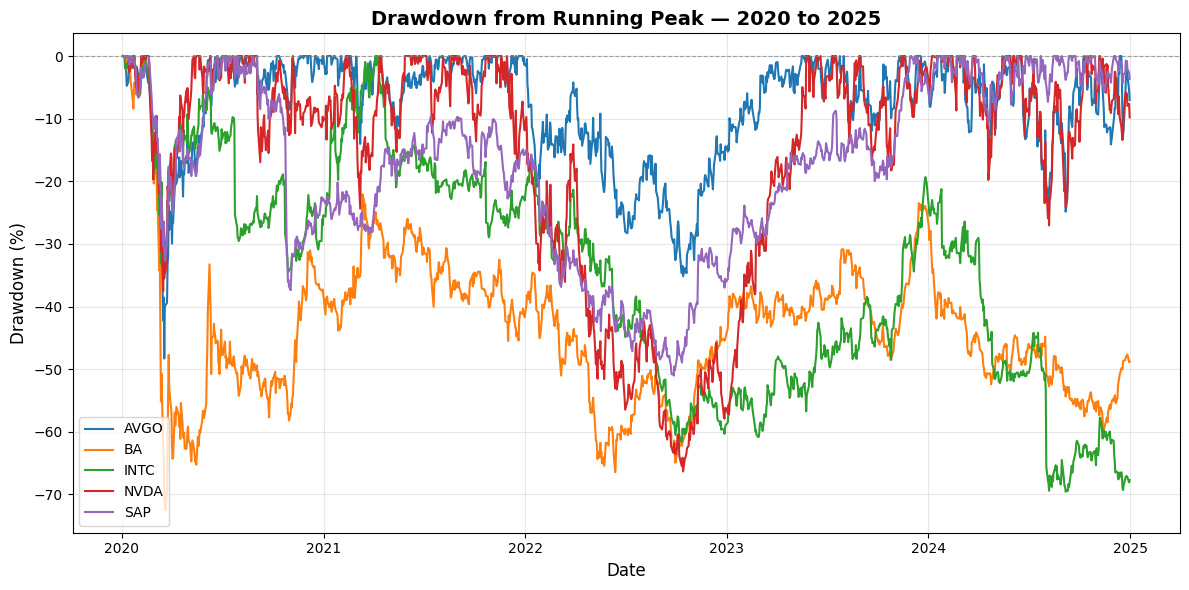

In [21]:
# plotting drawdowns over time
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in drawdown.columns:
    ax.plot(drawdown.index, drawdown[ticker] * 100, linewidth=1.5, label=ticker)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_title('Drawdown from Running Peak — 2020 to 2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

### Observations

- **NVDA's headline return came with a -60% drawdown in 2022.** Investors who panic-sold during the tech selloff missed the entire AI-driven recovery. The 2,148% total return is real, but only investors with the conviction to sit through a 60% loss captured it.

- **BA and INTC are still underwater years later.** BA's -60%+ COVID drawdown never fully recovered, and INTC's slow grind from 2021 onward reflects deteriorating competitive position. These two are case studies in how some drawdowns aren't temporary — they're permanent capital impairment.

- **AVGO and SAP had the shallowest drawdowns.** Both recovered to new highs relatively quickly after any decline. This is what investors mean by "quality" — not the highest returns, but the most resilient recovery profile.

- **Drawdown is what investors actually feel.** Volatility is an abstract number; drawdown is the lived experience of watching your portfolio fall and stay there. This is the metric clients fire managers over — even if the long-term Sharpe ratio is good.

### Observations on Sharpe Ratio

- **NVDA's Sharpe of 1.55 confirms it was a quality investment, not just a lucky one.** A 2,148% return with a 1.55 Sharpe means investors were genuinely compensated for the volatility they endured. This is the difference between skill and gambling.

- **AVGO (1.19) is the under-the-radar winner.** While NVDA grabbed headlines, AVGO delivered nearly as strong risk-adjusted returns with less volatility (41.89% vs. 53.88%). For risk-conscious investors, AVGO offered the more efficient exposure to the AI/semiconductor theme.

- **SAP (0.38) is the case study in "decent isn't good enough."** SAP made money — 14.52% annualized — but its risk-adjusted return is mediocre because the volatility (30.69%) ate too much of the upside. With the risk-free rate now at 4.585%, SAP-quality returns are even harder to justify.

- **BA (-0.29) and INTC (-0.48) had negative Sharpe ratios — the worst possible outcome.** Investors took on equity-level risk and earned less than a risk-free Treasury would have paid. These are not "bad luck" stories; they are case studies in opportunity cost.

- **Ranking by Sharpe matches ranking by total return — which is unusual.** Often, lower-volatility stocks outrank flashy winners on a risk-adjusted basis. In this basket, the headline winners were *also* the most efficient — and the losers were doubly punished by losing money AND being volatile.

## Phase 4: Portfolio Construction & Benchmark Comparison

Individual stock analysis tells me which names performed best in isolation. But investors don't hold one stock — they hold portfolios. This phase combines the five stocks into a single weighted portfolio, simulates how a $10,000 initial investment would have grown, and compares the result to the S&P 500 benchmark.

### Methodology

- **Portfolio composition — conviction-weighted toward AI and growth themes:**
    - **NVDA: 30%** — highest conviction on AI infrastructure leadership
    - **AVGO: 25%** — secondary AI exposure with stronger dividend profile
    - **SAP: 20%** — defensive enterprise software anchor, lower correlation to semis
    - **BA: 15%** — turnaround/recovery exposure with industrial diversification
    - **INTC: 10%** — smallest weight reflecting competitive concerns
- **Initial investment:** $10,000
- **Benchmark:** SPY (S&P 500 ETF) — the standard "do nothing fancy" comparison every active strategy must beat to justify itself.
- **Rebalancing:** None for this baseline test. The portfolio drifts naturally, meaning winners grow as a share of total value and losers shrink. This is realistic for a buy-and-hold investor.

The weighting reflects a thesis: AI infrastructure (NVDA + AVGO = 55%) will outperform, while maintaining diversification through SAP and selective exposure t

In [22]:
# defining portfolio weights (conviction-weighted, AI-tilted)
weights = pd.Series({
    'NVDA': 0.30,
    'AVGO': 0.25,
    'SAP':  0.20,
    'BA':   0.15,
    'INTC': 0.10
})

# confirming weights sum to 100%
print(f"Total weight: {weights.sum() * 100:.0f}%")
print(weights)

Total weight: 100%
NVDA    0.30
AVGO    0.25
SAP     0.20
BA      0.15
INTC    0.10
dtype: float64


### Pulling the Benchmark (S&P 500)

For the benchmark, I'll pull the same 5-year window of SPY (the most liquid S&P 500 ETF) and align it with the portfolio data.

In [25]:
# pulling S&P 500 data for the benchmark
spy = yf.download(tickers = "SPY",
                  start   = "2020-01-01",
                  end     = "2025-01-01")['Close']

# flatten to a Series in case yfinance returns a DataFrame
if isinstance(spy, pd.DataFrame):
    spy = spy.squeeze()

# converting to daily returns
spy_returns = spy.pct_change().dropna()

print(f"SPY data points: {len(spy_returns)}")
spy.tail()

[*********************100%***********************]  1 of 1 completed

SPY data points: 1257


Date
2024-12-24    592.702087
2024-12-26    592.741577
2024-12-27    586.502075
2024-12-30    579.809082
2024-12-31    577.699768
Name: SPY, dtype: float64

### Calculating Portfolio Returns

For a portfolio with fixed weights, the daily return is simply the weighted average of each stock's daily return. From there, I can build the cumulative growth path and translate it to the dollar value of an initial $10,000 investment.

In [26]:
# initial investment
initial_investment = 10000

# portfolio daily return = weighted average of stock returns
portfolio_returns = (daily_returns * weights).sum(axis=1)

# cumulative growth path (starting from 1)
portfolio_cumulative = (1 + portfolio_returns).cumprod()
spy_cumulative       = (1 + spy_returns).cumprod()

# dollar value over time
portfolio_value = portfolio_cumulative * initial_investment
spy_value       = spy_cumulative * initial_investment

# final values
print(f"Portfolio final value: ${portfolio_value.iloc[-1]:,.2f}")
print(f"S&P 500 final value:   ${spy_value.iloc[-1]:,.2f}")
print(f"Difference:            ${portfolio_value.iloc[-1] - spy_value.iloc[-1]:,.2f}")

Portfolio final value: $50,305.05
S&P 500 final value:   $19,458.50
Difference:            $30,846.55


### Equity Curve: Portfolio vs. S&P 500

The chart below shows how $10,000 invested in each strategy would have grown over the 5-year window. This is the single most important visual in any backtest — it answers the headline question: did the strategy beat the benchmark?

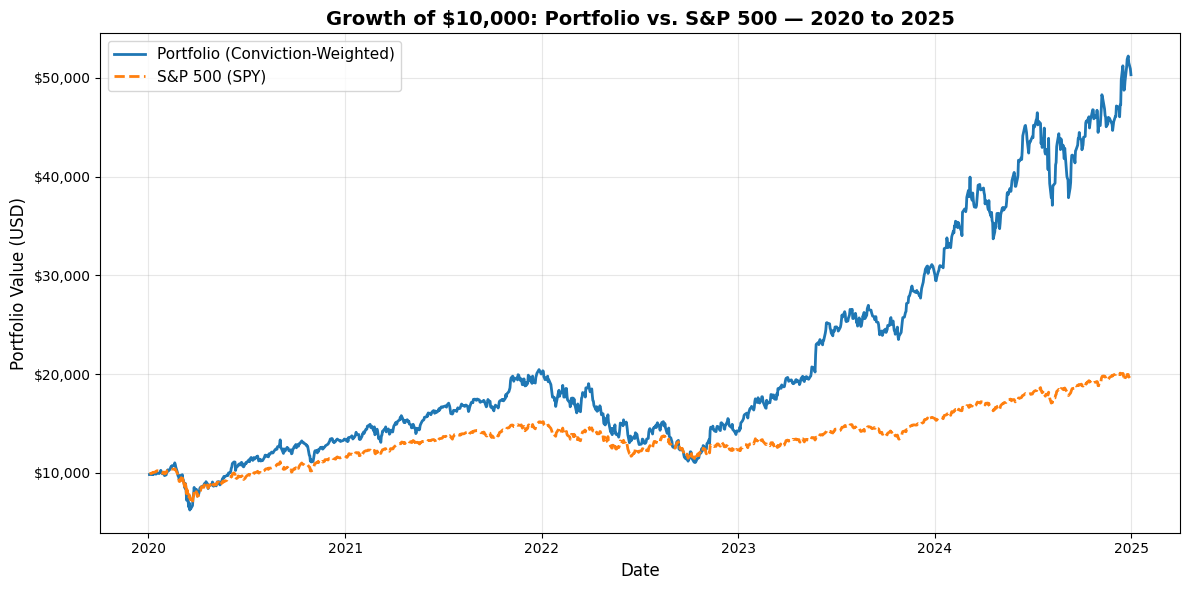

In [27]:
# plotting equity curve: portfolio vs. S&P 500
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(portfolio_value.index, portfolio_value, linewidth=2,
        label='Portfolio (Conviction-Weighted)', color='#1f77b4')
ax.plot(spy_value.index, spy_value, linewidth=2,
        label='S&P 500 (SPY)', color='#ff7f0e', linestyle='--')

ax.set_title('Growth of $10,000: Portfolio vs. S&P 500 — 2020 to 2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value (USD)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

### Portfolio vs. Benchmark: Full Performance Comparison

Calculating the same five metrics from Phase 3 — total return, annualized return, volatility, Sharpe ratio, and max drawdown — for both the portfolio and the S&P 500 benchmark.

In [28]:
# helper function to calculate all metrics for any return series
def calculate_metrics(returns, name):
    total_ret = (1 + returns).prod() - 1
    n         = len(returns)
    ann_ret   = ((1 + total_ret) ** (252 / n)) - 1
    ann_vol   = returns.std() * (252 ** 0.5)
    sharpe    = (ann_ret - 0.03) / ann_vol
    
    cum       = (1 + returns).cumprod()
    runmax    = cum.cummax()
    dd        = (cum - runmax) / runmax
    max_dd    = dd.min()
    
    return pd.Series({
        'Total Return (%)':          round(total_ret * 100, 2),
        'Annualized Return (%)':     round(ann_ret * 100, 2),
        'Annualized Volatility (%)': round(ann_vol * 100, 2),
        'Sharpe Ratio':              round(sharpe, 2),
        'Max Drawdown (%)':          round(max_dd * 100, 2)
    }, name=name)

# building comparison table
comparison = pd.DataFrame([
    calculate_metrics(portfolio_returns, 'Portfolio (Conviction-Weighted)'),
    calculate_metrics(spy_returns,       'S&P 500 (SPY)')
])

comparison

,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
Portfolio (Conviction-Weighted),403.05,38.25,35.02,1.01,-45.92
S&P 500 (SPY),94.58,14.28,21.00,0.54,-33.72


### Observations

- **The portfolio delivered roughly 4x the S&P 500's total return** (403% vs. 95%) over the 5-year window — a $30,800 absolute dollar advantage on a $10,000 starting investment.

- **The win was risk-adjusted, not just absolute.** Sharpe ratio of 1.01 vs. SPY's 0.54 means the portfolio generated nearly double the return per unit of risk taken. This is the metric that separates skill from luck: anyone can beat the market by concentrating in volatile names, but doing so *efficiently* requires good selection.

- **Higher returns came with materially higher risk.** Portfolio volatility (35.02%) was 67% higher than SPY's (21.00%), and the max drawdown (-45.92%) was 12 points deeper than SPY's (-33.72%). At its worst, the portfolio was down nearly half its peak value — a drop that would test most investors' conviction.

- **The conviction-weighting paid off.** Overweighting NVDA and AVGO (55% combined) captured the AI boom; underweighting INTC (10%) limited the drag from its multi-year decline.

- **Real-world caveat: this only works if you don't panic.** A -46% drawdown is psychologically brutal. The 403% return was only available to investors who held through the 2022 tech selloff. Most retail investors sell at -20% to -30%, which would have locked in the loss and missed the recovery.

- **Setting up Phase 5: should I have rebalanced?** As NVDA grew, it became an increasingly dominant share of the portfolio. By the end, the "30%" allocation had drifted to likely 50%+. The next phase will test whether disciplined rebalancing would have improved or worsened the outcome.

## Phase 5: Strategy Comparison

A single backtest result is interesting; a comparison across multiple strategies is informative. This phase tests how the conviction-weighted portfolio performs against three alternative weighting schemes — each representing a different investment philosophy — and against the S&P 500 benchmark.

### The Four Strategies

| Strategy | Philosophy | NVDA | AVGO | SAP | BA | INTC |
|----------|------------|------|------|-----|------|------|
| **Conviction-Weighted** | AI tilt with defensive anchor | 30% | 25% | 20% | 15% | 10% |
| **Equal Weight** | No opinion; pure diversification | 20% | 20% | 20% | 20% | 20% |
| **AI-Maximalist** | Maximum exposure to AI winners | 50% | 30% | 10% | 5% | 5% |
| **Defensive** | Capital preservation focus | 10% | 15% | 50% | 15% | 10% |

The point isn't to find the "best" portfolio in hindsight — that's data mining. The point is to compare different investment philosophies on a like-for-like basis and understand the trade-offs each makes between return, risk, and drawdown.

In [29]:
# defining all four weighting strategies
strategies = {
    'Conviction-Weighted': pd.Series({'NVDA': 0.30, 'AVGO': 0.25, 'SAP': 0.20, 'BA': 0.15, 'INTC': 0.10}),
    'Equal Weight':        pd.Series({'NVDA': 0.20, 'AVGO': 0.20, 'SAP': 0.20, 'BA': 0.20, 'INTC': 0.20}),
    'AI-Maximalist':       pd.Series({'NVDA': 0.50, 'AVGO': 0.30, 'SAP': 0.10, 'BA': 0.05, 'INTC': 0.05}),
    'Defensive':           pd.Series({'NVDA': 0.10, 'AVGO': 0.15, 'SAP': 0.50, 'BA': 0.15, 'INTC': 0.10})
}

# confirming each strategy's weights sum to 100%
for name, w in strategies.items():
    print(f"{name:25s} weights sum to: {w.sum() * 100:.0f}%")

Conviction-Weighted       weights sum to: 100%
Equal Weight              weights sum to: 100%
AI-Maximalist             weights sum to: 100%
Defensive                 weights sum to: 100%


### Calculating Performance Across All Strategies

For each strategy, calculate daily returns, build the cumulative growth path, and capture the same five performance metrics for direct comparison.

In [30]:
# calculating returns and value paths for each strategy
strategy_returns = {}
strategy_values  = {}

for name, w in strategies.items():
    rets = (daily_returns * w).sum(axis=1)
    strategy_returns[name] = rets
    strategy_values[name]  = (1 + rets).cumprod() * initial_investment

# adding SPY as benchmark
strategy_values['S&P 500 (SPY)'] = spy_cumulative * initial_investment

# converting to DataFrames for easier handling
strategy_returns_df = pd.DataFrame(strategy_returns)
strategy_values_df  = pd.DataFrame(strategy_values)

# final values
print("Final Portfolio Values ($10,000 initial investment)")
print("-" * 55)
final_values = strategy_values_df.iloc[-1].sort_values(ascending=False)
for name, val in final_values.items():
    print(f"{name:25s} ${val:>12,.2f}")

Final Portfolio Values ($10,000 initial investment)
-------------------------------------------------------
AI-Maximalist             $  103,457.87
Conviction-Weighted       $   50,305.05
Equal Weight              $   29,503.99
Defensive                 $   25,797.18
S&P 500 (SPY)             $   19,458.50


### Equity Curves: All Strategies Side by Side

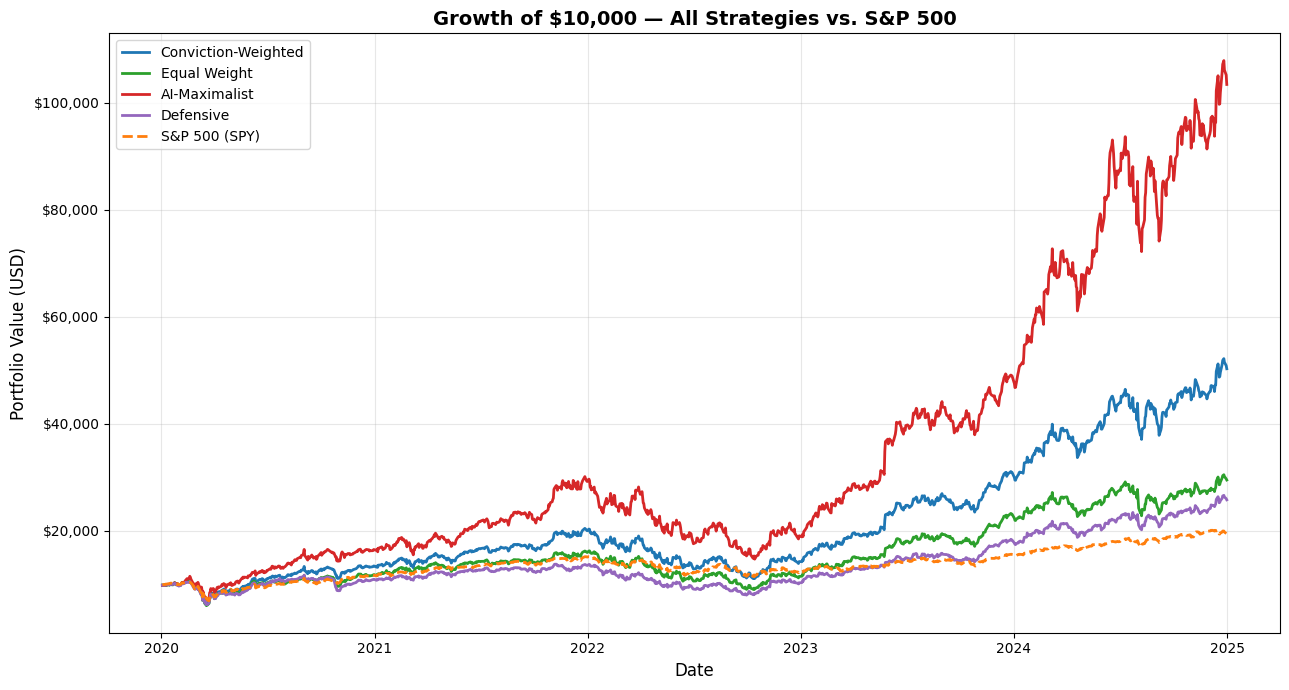

In [32]:
# plotting all strategies on one chart
fig, ax = plt.subplots(figsize=(13, 7))

colors = {
    'Conviction-Weighted': '#1f77b4',
    'Equal Weight':        '#2ca02c',
    'AI-Maximalist':       '#d62728',
    'Defensive':           '#9467bd',
    'S&P 500 (SPY)':       '#ff7f0e'
}

for name in strategy_values_df.columns:
    style = '--' if name == 'S&P 500 (SPY)' else '-'
    ax.plot(strategy_values_df.index, strategy_values_df[name],
            linewidth=2, label=name, color=colors[name], linestyle=style)

ax.set_title('Growth of $10,000 — All Strategies vs. S&P 500',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value (USD)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### Full Performance Comparison Table

The headline output: every strategy evaluated on every metric.

In [33]:
# building full comparison table for all strategies + benchmark
all_results = []

for name in strategies.keys():
    all_results.append(calculate_metrics(strategy_returns[name], name))

# add benchmark
all_results.append(calculate_metrics(spy_returns, 'S&P 500 (SPY)'))

final_comparison = pd.DataFrame(all_results)

# sort by Sharpe ratio (best risk-adjusted return first)
final_comparison = final_comparison.sort_values('Sharpe Ratio', ascending=False)

final_comparison

,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
AI-Maximalist,934.58,59.75,40.57,1.40,-51.23
Conviction-Weighted,403.05,38.25,35.02,1.01,-45.92
Equal Weight,195.04,24.22,33.47,0.63,-44.44
Defensive,157.97,20.92,30.18,0.59,-41.97
S&P 500 (SPY),94.58,14.28,21.00,0.54,-33.72


### Final Insights

- **Every strategy beat the S&P 500 on both return and Sharpe.** Even the Defensive portfolio (Sharpe 0.59) edged out SPY (0.54), confirming the basket itself was well-selected. Stock selection mattered before weighting did.

- **AI-Maximalist won on every dimension.** Highest total return (934.58%), highest annualized return (59.75%), AND highest Sharpe (1.40). Maximum concentration in the two highest-Sharpe individual stocks (NVDA: 1.55, AVGO: 1.19) produced the best portfolio outcome.

- **This contradicts textbook diversification advice — but only in this specific context.** Standard portfolio theory says diversification improves risk-adjusted returns. In this basket, adding more BA and INTC actively HURT Sharpe because both had negative individual Sharpe ratios. Diversification only helps when the additions have positive risk-adjusted returns of their own.

- **The Conviction-Weighted portfolio (Sharpe 1.01) is the realistic real-world winner.** AI-Maximalist outperformed it in hindsight, but holding 80% of your money in two semiconductors requires a level of conviction most investors won't sustain through a -51% drawdown. Conviction-Weighted balances upside capture with diversification — the sustainable middle path.

- **Drawdown scaled directly with concentration.** AI-Maximalist's -51.23% drawdown was the worst; Defensive's -41.97% was the shallowest. Concentrating in winners means accepting deeper troughs along the way. There is no free lunch.

- **The benchmark was beaten on a risk-adjusted basis by all four strategies — not just on raw return.** Anyone can beat the market by taking more risk. Beating the market on Sharpe means the stock selection added genuine value, not just leverage.